# 05. Regression Discontinuity

Regression discontinuity design, usually abbreviated RD or RDD, is a quasi-experimental design for settings where treatment assignment changes sharply at a known threshold. The threshold might be a credit score, fraud-risk score, lead score, model confidence score, customer health score, revenue tier, age cutoff, shipment distance cutoff, or eligibility score.

The central idea is simple: units just below and just above the cutoff should be comparable if they cannot precisely sort around the threshold. When that design story is credible, the jump in the outcome at the cutoff can be interpreted as a local causal effect.

This notebook treats RD as an industry design pattern. Many companies already use threshold rules in operations. The causal question is whether the action triggered by the threshold actually improves the downstream outcome.

## Learning Goals

By the end of this notebook, you should be able to:

- Recognize when a threshold policy creates an RD opportunity.
- Distinguish sharp RD from fuzzy RD.
- Define the local treatment effect at the cutoff.
- Estimate a sharp RD effect with local linear regression.
- Explain why bandwidth choice matters.
- Use RD plots, bandwidth sensitivity, density checks, covariate balance, placebo cutoffs, and donut checks.
- Diagnose manipulation or sorting around the cutoff.
- Understand how fuzzy RD becomes an instrumental variables problem.
- Translate an RD analysis into an industry decision readout.

## Mathematical Setup: Local Identification at a Cutoff

Regression discontinuity is built around a local comparison. Let $X_i$ be the running variable, $c$ the cutoff, and $D_i=1[X_i \ge c]$ in a sharp design. The target is the jump in the conditional expectation of the outcome at the cutoff:

$$
\tau_{RD} = \lim_{x \downarrow c}E[Y_i \mid X_i=x] - \lim_{x \uparrow c}E[Y_i \mid X_i=x]
$$

The continuity assumption says that, without treatment, the potential-outcome regression functions would be smooth through the cutoff:

$$
\lim_{x \downarrow c}E[Y_i(0) \mid X_i=x] = \lim_{x \uparrow c}E[Y_i(0) \mid X_i=x]
$$

A local linear estimator fits the outcome near the cutoff, often with kernel weights:

$$
K_h(X_i-c) = K\left(\frac{X_i-c}{h}\right)
$$

The bandwidth $h$ controls the bias-variance tradeoff. Narrow windows compare closer units but use less data. Wider windows use more data but lean harder on the local linear approximation.

In [1]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio project root so shared notebook utilities can be imported.
    
    Idea:
        The notebooks may be executed from different working directories, so this helper walks upward until it finds the repository structure used by the lecture series.
    
    Args:
        start: Directory where the upward search for the project root begins.
    
    Returns:
        pathlib.Path: Absolute path to the portfolio project root.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings

import graphviz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import Markdown, display
from scipy import stats

try:
    from rdrobust import rdrobust
except ModuleNotFoundError:
    rdrobust = None

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)

from notebooks._shared.display import smart_display

In [2]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    """
    Create a styled Graphviz causal or design diagram for the lecture.
    
    Idea:
        The diagram makes assumptions, assignment mechanisms, and diagnostic workflows visible before the code estimates an effect.
    
    Args:
        edges: Directed edges from source node to target node in the causal or design diagram.
        title: Title displayed on the Graphviz or Matplotlib figure.
        node_colors: Optional mapping from node labels to fill colors.
        rankdir: Graphviz layout direction, such as left-to-right or top-to-bottom.
    
    Returns:
        graphviz.Digraph: Renderable diagram object for display in the notebook.
    """
    graph = graphviz.Digraph(format="svg")
    graph.attr(rankdir=rankdir, bgcolor="white", pad="0.2")
    graph.attr("node", shape="box", style="rounded,filled", color="#334155", fontname="Helvetica")
    graph.attr("edge", color="#475569", arrowsize="0.8")

    node_colors = node_colors or {}
    nodes = sorted({node for edge in edges for node in edge[:2]})
    for node in nodes:
        graph.node(node, fillcolor=node_colors.get(node, "#eef2ff"))

    for edge in edges:
        if len(edge) == 2:
            graph.edge(edge[0], edge[1])
        else:
            graph.edge(edge[0], edge[1], label=edge[2])

    if title:
        graph.attr(label=title, labelloc="t", fontsize="18", fontname="Helvetica-Bold")
    return graph


def triangular_kernel(running, bandwidth):
    """Compute triangular kernel weights for local RD estimation.

    Args:
        running: Centered running variable values used by the RD kernel.
        bandwidth: Local window around the cutoff used for RD estimation.

    Returns:
        numpy.ndarray: Local-linear RD kernel weights.
    """
    scaled = np.abs(np.asarray(running, dtype=float)) / bandwidth
    return np.clip(1 - scaled, 0, None)


def fit_local_linear_rd(data, outcome, score, cutoff=0.0, bandwidth=0.75, covariates=None):
    """Fit a local linear RD model with triangular kernel weights.

    Args:
        data: Analysis DataFrame containing the variables used by the helper.
        outcome: Outcome variable name or vector being analyzed.
        score: Running variable or propensity score used by the design.
        cutoff: Threshold defining assignment or the RD comparison point.
        bandwidth: Local window around the cutoff used for RD estimation.
        covariates: List of covariates used for adjustment or diagnostics.

    Returns:
        dict: RD estimate, uncertainty, fitted model, and local data.
    """
    covariates = covariates or []
    work = data.loc[(data[score] - cutoff).abs() < bandwidth].copy()
    work["running"] = work[score] - cutoff
    work["treated_side"] = (work[score] >= cutoff).astype(int)
    work["treated_x_running"] = work["treated_side"] * work["running"]

    design_cols = ["treated_side", "running", "treated_x_running"]
    covariate_terms = []
    for covariate in covariates:
        term = f"{covariate}_centered"
        work[term] = work[covariate] - work[covariate].mean()
        design_cols.append(term)
        covariate_terms.append(term)

    X = sm.add_constant(work[design_cols], has_constant="add")
    weights = triangular_kernel(work["running"], bandwidth)
    model = sm.WLS(work[outcome], X, weights=weights)
    fitted = model.fit(cov_type="HC1")

    estimate = float(fitted.params["treated_side"])
    se = float(fitted.bse["treated_side"])
    ci_low = estimate - 1.96 * se
    ci_high = estimate + 1.96 * se

    return {
        "estimate": estimate,
        "se": se,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "p_value": float(fitted.pvalues["treated_side"]),
        "bandwidth": bandwidth,
        "cutoff": cutoff,
        "n": int(len(work)),
        "n_left": int((work[score] < cutoff).sum()),
        "n_right": int((work[score] >= cutoff).sum()),
        "model": fitted,
        "covariate_terms": covariate_terms,
        "data": work,
    }


def result_row(label, result):
    """Convert an RD result dictionary into one display-ready summary row.

    Args:
        label: Human-readable label for the row or scenario being produced.
        result: Fitted-result dictionary or model output to summarize.

    Returns:
        dict: Display-ready row for an RD specification.
    """
    return {
        "specification": label,
        "estimate": result["estimate"],
        "std_error": result["se"],
        "ci_low": result["ci_low"],
        "ci_high": result["ci_high"],
        "p_value": result["p_value"],
        "bandwidth": result["bandwidth"],
        "n": result["n"],
        "n_left": result["n_left"],
        "n_right": result["n_right"],
    }


def predict_rd_line(result, x_values):
    """Predict fitted RD lines on a grid of running-variable values.

    Args:
        result: Fitted-result dictionary or model output to summarize.
        x_values: Grid of running-variable values at which to predict the RD fit.

    Returns:
        numpy.ndarray: Predicted RD fit values on the supplied grid.
    """
    x_values = np.asarray(x_values)
    running = x_values - result["cutoff"]
    treated_side = (x_values >= result["cutoff"]).astype(int)
    X = pd.DataFrame(
        {
            "const": 1.0,
            "treated_side": treated_side,
            "running": running,
            "treated_x_running": treated_side * running,
        }
    )
    for term in result["covariate_terms"]:
        X[term] = 0.0
    X = X[result["model"].model.exog_names]
    return result["model"].predict(X)


def make_rd_bins(data, score, outcome, bin_width=0.10, score_min=-2.5, score_max=2.5):
    """Bin running-variable values and compute mean outcomes for RD plots.

    Args:
        data: Analysis DataFrame containing the variables used by the helper.
        score: Running variable or propensity score used by the design.
        outcome: Outcome variable name or vector being analyzed.
        bin_width: Width of bins used to aggregate scatter points for plotting.
        score_min: Lower running-variable value included in binned summaries.
        score_max: Upper running-variable value included in binned summaries.

    Returns:
        pandas.DataFrame: Binned running-variable means and counts.
    """
    bins = np.arange(score_min, score_max + bin_width, bin_width)
    work = data.loc[data[score].between(score_min, score_max)].copy()
    work["bin"] = pd.cut(work[score], bins=bins, include_lowest=True)
    binned = (
        work.groupby("bin", observed=True)
        .agg(
            score_mid=(score, "mean"),
            outcome_mean=(outcome, "mean"),
            n=(outcome, "size"),
        )
        .reset_index(drop=True)
    )
    return binned


def plot_rd(data, outcome, score, result, title, ylabel, bin_width=0.10, sample_size=1200):
    """Plot raw observations, binned means, local fits, and the RD cutoff.

    Args:
        data: Analysis DataFrame containing the variables used by the helper.
        outcome: Outcome variable name or vector being analyzed.
        score: Running variable or propensity score used by the design.
        result: Fitted-result dictionary or model output to summarize.
        title: Title shown on the resulting figure.
        ylabel: Y-axis label for the resulting figure.
        bin_width: Width of bins used to aggregate scatter points for plotting.
        sample_size: Maximum number of raw observations drawn for a plot.

    Returns:
        tuple: Matplotlib figure and axes for the RD diagnostic plot.
    """
    rng = np.random.default_rng(2026)
    plot_data = data.sample(min(sample_size, len(data)), random_state=2026)
    binned = make_rd_bins(data, score, outcome, bin_width=bin_width)
    bandwidth = result["bandwidth"]
    cutoff = result["cutoff"]
    left_grid = np.linspace(cutoff - bandwidth, cutoff, 160, endpoint=False)
    right_grid = np.linspace(cutoff, cutoff + bandwidth, 160)

    fig, ax = plt.subplots(figsize=(10, 5.2))
    ax.scatter(plot_data[score], plot_data[outcome], s=12, alpha=0.10, color="#64748b", label="Accounts")
    ax.scatter(binned["score_mid"], binned["outcome_mean"], s=np.clip(binned["n"] * 0.8, 20, 90), color="#0f766e", label="Binned means")
    ax.plot(left_grid, predict_rd_line(result, left_grid), color="#2563eb", linewidth=2.5, label="Local fit below cutoff")
    ax.plot(right_grid, predict_rd_line(result, right_grid), color="#dc2626", linewidth=2.5, label="Local fit above cutoff")
    ax.axvline(cutoff, color="#111827", linestyle="--", linewidth=1.5, label="Eligibility cutoff")
    ax.set_title(title)
    ax.set_xlabel("Centered risk score: threshold at 0")
    ax.set_ylabel(ylabel)
    ax.legend(loc="best")
    return fig, ax

## 1. Where Regression Discontinuity Fits

An RD design appears when a rule assigns treatment based on whether a running variable crosses a known cutoff. In a sharp RD, crossing the threshold completely determines treatment. In a fuzzy RD, crossing the threshold changes the probability of treatment but does not fully determine who receives it.

Classic RD was introduced by Thistlethwaite and Campbell (1960). Modern econometric treatments emphasize that the estimand is local to the cutoff: RD estimates what happens for units at the threshold, not necessarily for units far away from it (Hahn et al., 2001; Imbens & Lemieux, 2008; Lee & Lemieux, 2010; Cattaneo & Titiunik, 2022).

Industry examples are everywhere:

- Customers with health score above a cutoff are routed to a retention desk.
- Transactions with fraud risk above a cutoff receive manual review.
- Leads with propensity score above a cutoff receive sales outreach.
- Warehouses above a backlog threshold get emergency labor allocation.
- Listings above a quality score are promoted in search.
- Borrowers below a credit threshold are denied or receive a different loan offer.

The design question is whether units close to the threshold are comparable enough that the discontinuity in outcomes can be attributed to the policy triggered by the threshold.

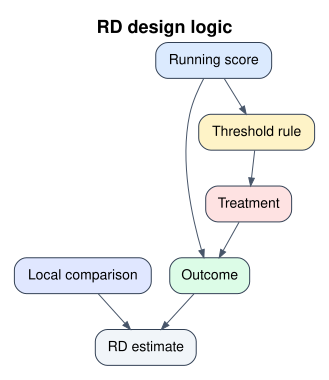

In [3]:
# Organize the calculation into readable steps for the lecture narrative.
make_dag(
    edges=[
        ("Running score", "Threshold rule"),
        ("Threshold rule", "Treatment"),
        ("Treatment", "Outcome"),
        ("Running score", "Outcome"),
        ("Local comparison", "RD estimate"),
        ("Outcome", "RD estimate"),
    ],
    title="RD design logic",
    node_colors={
        "Running score": "#dbeafe",
        "Threshold rule": "#fef3c7",
        "Treatment": "#fee2e2",
        "Outcome": "#dcfce7",
        "Local comparison": "#e0e7ff",
        "RD estimate": "#f1f5f9",
    },
    rankdir="TB",
)

The running score can affect the outcome directly. That is not a problem. RD does not require the score to be unrelated to the outcome. It requires the potential outcome functions to be smooth through the cutoff in the absence of treatment. The discontinuity created by the rule is the causal signal.

## 2. Sharp RD Estimand

Let $X_i$ be the running variable, $c$ be the cutoff, $D_i$ be treatment, and $Y_i$ be the observed outcome. In a sharp RD:

$$
D_i = 1[X_i \ge c]
$$

The sharp RD estimand is the jump in the conditional expectation of the outcome at the cutoff:

$$
\tau_{SRD} = \lim_{x \downarrow c} E[Y_i \mid X_i = x] - \lim_{x \uparrow c} E[Y_i \mid X_i = x]
$$

Under continuity of the untreated and treated potential outcome regression functions at the cutoff, this jump identifies the average treatment effect for units at the cutoff.

That last phrase is the most important phrase in the notebook: for units at the cutoff. RD is high-credibility but local.

## 3. Running Example: Customer Retention Desk

Suppose a SaaS company has a customer health model. Accounts with a centered risk score at or above zero are routed to a priority retention desk. The outcome is 90-day renewal margin in thousands of dollars.

Business question:

> For accounts close to the operational risk threshold, does priority retention support increase 90-day renewal margin?

This is a sharp RD because eligibility is deterministic: all accounts above the cutoff receive the retention workflow, and all accounts below it do not.

**Dataset and experiment setup.** The RD dataset represents accounts scored by a centered retention-risk rule. Accounts just above the cutoff are assigned to a retention desk, while accounts just below are not. The outcome is 90-day renewal margin, and pre-treatment variables include prior spend, usage, and plan type. The design is local: far-away accounts can be very different, but accounts near the cutoff should be comparable if the score cannot be precisely manipulated. The simulation includes a known jump at the cutoff, smooth baseline relationships, and later a manipulated-score failure mode to make the identifying assumption visible.

In [4]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def bounded_normal(rng, n, mean=0.0, sd=0.9, low=-2.5, high=2.5):
    """
    Draw normal random values and truncate them to a meaningful score range.
    
    Idea:
        The helper creates running variables and covariates that stay inside realistic bounds for the regression-discontinuity example.
    
    Args:
        rng: NumPy random generator used for reproducible draws.
        n: Number of observations to simulate or draw.
        mean: Center of the normal distribution before bounding.
        sd: Standard deviation of the normal distribution before bounding.
        low: Lower bound imposed on the generated values.
        high: Upper bound imposed on the generated values.
    
    Returns:
        numpy.ndarray: Bounded random draws with the requested length.
    """
    draws = []
    needed = n
    while needed > 0:
        candidate = rng.normal(mean, sd, size=max(needed * 3, 1000))
        candidate = candidate[(candidate > low) & (candidate < high)]
        draws.append(candidate[:needed])
        needed -= len(draws[-1])
    return np.concatenate(draws)


def simulate_rdd_data(n=6000, seed=5505, manipulation=False):
    """Generate the synthetic rdd data data used in 05. Regression Discontinuity.

    Args:
        n: Number of simulated units.
        seed: Random seed used for reproducibility.
        manipulation: Whether to simulate score manipulation near the cutoff.

    Returns:
        pandas.DataFrame: Simulated dataset with observed variables and known teaching truth where needed.
    """
    rng = np.random.default_rng(seed)
    latent_score = bounded_normal(rng, n)
    observed_score = latent_score.copy()

    if manipulation:
        can_move = (latent_score > -0.22) & (latent_score < 0)
        movers = can_move & (rng.uniform(size=n) < 0.55)
        observed_score[movers] = rng.uniform(0.005, 0.18, size=movers.sum())

    pre_spend = 120 + 16 * latent_score + rng.normal(0, 12, size=n)
    usage_last_30 = 42 + 7.5 * latent_score + rng.normal(0, 6, size=n)
    enterprise_prob = 1 / (1 + np.exp(-(-0.15 + 0.35 * latent_score)))
    enterprise_plan = rng.binomial(1, enterprise_prob, size=n)

    assigned_retention = (observed_score >= 0).astype(int)
    true_effect = 6.0 + 1.2 * latent_score

    untreated_margin = (
        58
        + 0.085 * pre_spend
        + 0.38 * usage_last_30
        + 4.0 * enterprise_plan
        + 7.0 * latent_score
        - 5.5 * latent_score**2
        + 1.8 * latent_score**3
        + rng.normal(0, 8.5, size=n)
    )
    renewal_margin = untreated_margin + assigned_retention * true_effect

    return pd.DataFrame(
        {
            "account_id": np.arange(1, n + 1),
            "risk_score": observed_score,
            "latent_risk_score": latent_score,
            "assigned_retention": assigned_retention,
            "renewal_margin": renewal_margin,
            "true_effect": true_effect,
            "pre_spend": pre_spend,
            "usage_last_30": usage_last_30,
            "enterprise_plan": enterprise_plan,
        }
    )


df_rdd = simulate_rdd_data()
summary = pd.DataFrame(
    {
        "value": {
            "accounts": len(df_rdd),
            "share_assigned": df_rdd["assigned_retention"].mean(),
            "avg_margin": df_rdd["renewal_margin"].mean(),
            "avg_pre_spend": df_rdd["pre_spend"].mean(),
            "avg_usage": df_rdd["usage_last_30"].mean(),
        }
    }
)
smart_display(summary.round(3))

,value
accounts,6000.000
share_assigned,0.492
avg_margin,84.681
avg_pre_spend,119.731
avg_usage,41.712


The score is centered so the cutoff is zero. Accounts just below zero miss the priority workflow. Accounts just above zero receive it.

The data generating process intentionally makes the running variable predictive of the outcome. Higher-risk accounts differ from lower-risk accounts. That is expected in RD. The design compares accounts very close to the threshold, where smooth differences in risk can be modeled and the threshold jump is isolated.

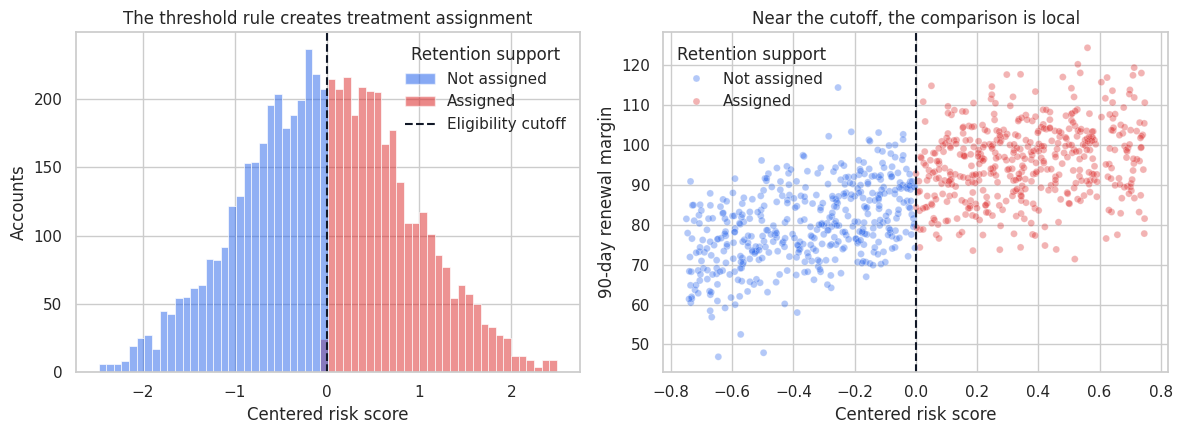

In [5]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_df = df_rdd.assign(
    assignment_label=np.where(df_rdd["assigned_retention"].eq(1), "Assigned", "Not assigned")
)
assignment_palette = {"Not assigned": "#2563eb", "Assigned": "#dc2626"}

sns.histplot(
    plot_df,
    x="risk_score",
    hue="assignment_label",
    hue_order=["Not assigned", "Assigned"],
    bins=60,
    ax=axes[0],
    palette=assignment_palette,
    legend=False,
)
axes[0].axvline(0, color="#111827", linestyle="--", linewidth=1.5)
axes[0].set_title("The threshold rule creates treatment assignment")
axes[0].set_xlabel("Centered risk score")
axes[0].set_ylabel("Accounts")
axes[0].legend(
    handles=[
        Patch(facecolor=assignment_palette["Not assigned"], alpha=0.55, label="Not assigned"),
        Patch(facecolor=assignment_palette["Assigned"], alpha=0.55, label="Assigned"),
        Line2D([0], [0], color="#111827", linestyle="--", label="Eligibility cutoff"),
    ],
    title="Retention support",
    frameon=False,
)

near = plot_df.loc[plot_df["risk_score"].abs() <= 0.75].copy()
sns.scatterplot(
    data=near.sample(900, random_state=11),
    x="risk_score",
    y="renewal_margin",
    hue="assignment_label",
    hue_order=["Not assigned", "Assigned"],
    alpha=0.35,
    s=25,
    ax=axes[1],
    palette=assignment_palette,
)
axes[1].axvline(0, color="#111827", linestyle="--", linewidth=1.5)
axes[1].set_title("Near the cutoff, the comparison is local")
axes[1].set_xlabel("Centered risk score")
axes[1].set_ylabel("90-day renewal margin")
axes[1].legend(title="Retention support", frameon=False)

plt.tight_layout()
plt.show()

A naive comparison of all treated accounts to all untreated accounts is not credible because assignment is based on risk. Treated accounts are on the high-risk side of the score distribution. The RD comparison narrows attention to the neighborhood around zero.

In [6]:
# Assemble the Running Example: Customer Retention Desk summary table used for interpretation.
naive_table = (
    df_rdd.groupby("assigned_retention")
    .agg(
        accounts=("account_id", "count"),
        avg_score=("risk_score", "mean"),
        avg_margin=("renewal_margin", "mean"),
        avg_pre_spend=("pre_spend", "mean"),
        avg_usage=("usage_last_30", "mean"),
    )
    .rename(index={0: "Below cutoff", 1: "Above cutoff"})
)
naive_difference = naive_table.loc["Above cutoff", "avg_margin"] - naive_table.loc["Below cutoff", "avg_margin"]
smart_display(naive_table.round(3))
print(f"Naive difference in average renewal margin: {naive_difference:.2f}")
print(f"True causal effect at the cutoff in this simulation: {6.0:.2f}")

,accounts,avg_score,avg_margin,avg_pre_spend,avg_usage
assigned_retention,,,,,
Below cutoff,3048,-0.710,71.272,108.207,36.542
Above cutoff,2952,0.708,98.526,131.631,47.049


Naive difference in average renewal margin: 27.25
True causal effect at the cutoff in this simulation: 6.00


The naive difference mixes the treatment effect with smooth differences in the running score. If the running score is highly predictive, the all-treated versus all-control comparison answers the wrong question.

## 4. Local Linear RD

The workhorse estimator fits separate local regressions on each side of the cutoff. A common specification is:

$$
Y_i = \alpha + \tau D_i + \beta_1(X_i - c) + \beta_2D_i(X_i - c) + \epsilon_i
$$

estimated only within a bandwidth around the cutoff. The coefficient $\tau$ is the jump at the cutoff. We will use triangular kernel weights so observations closer to the cutoff receive more weight.

Local linear estimation is preferred to high-order global polynomials because RD is a boundary problem: the estimand is a limit at the threshold, not a global curve-fitting exercise.

In [7]:
# Assemble the Local Linear RD summary table used for interpretation.
main_rd = fit_local_linear_rd(
    df_rdd,
    outcome="renewal_margin",
    score="risk_score",
    cutoff=0.0,
    bandwidth=0.75,
)

main_table = pd.DataFrame([result_row("Local linear, h = 0.75", main_rd)])
smart_display(main_table.round(3))

,specification,estimate,std_error,ci_low,ci_high,p_value,bandwidth,n,n_left,n_right
0,"Local linear, h = 0.75",5.467,0.640,4.212,6.722,0.000,0.750,3618,1819,1799


In Local Linear RD, the table keeps attention on the neighborhood around the cutoff. Bandwidth sensitivity, covariate continuity, density checks, and placebo cutoffs are the credibility checks for the local contrast.

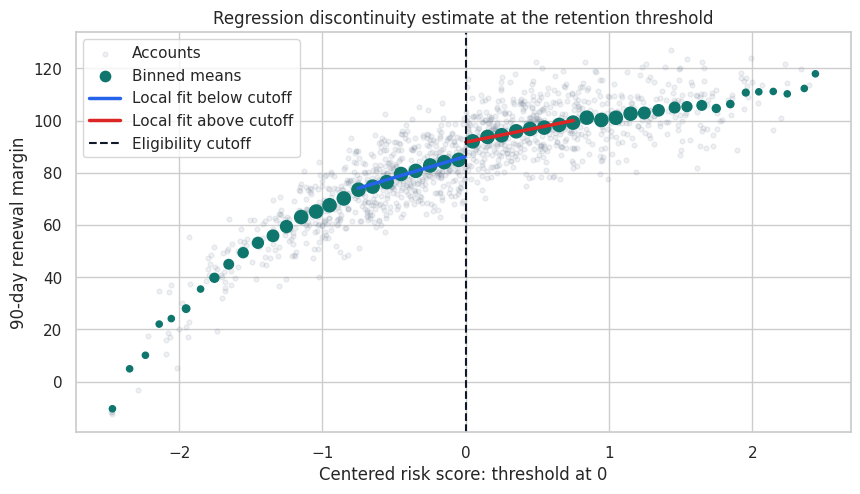

In [8]:
# Prepare the quantities used in the Local Linear RD discussion.
plot_rd(
    df_rdd,
    outcome="renewal_margin",
    score="risk_score",
    result=main_rd,
    title="Regression discontinuity estimate at the retention threshold",
    ylabel="90-day renewal margin",
)
plt.show()

The binned means show the outcome pattern without plotting thousands of points on top of each other. The fitted lines are estimated only inside the bandwidth. The vertical gap between the two fitted lines at zero is the RD estimate.

In this simulation, the true treatment effect at the cutoff is 6.0. The estimate should be close, but not exactly equal, because the data include noise and the estimator is local.

## 5. Bandwidth Sensitivity

Bandwidth is a bias-variance tradeoff.

- A narrow bandwidth compares very similar accounts but uses fewer observations.
- A wide bandwidth uses more data but relies more heavily on the functional-form approximation.

A credible RD analysis should not depend on one magical bandwidth. It should show whether the conclusion is stable across reasonable bandwidth choices.

In [9]:
# Assemble the Bandwidth Sensitivity summary table used for interpretation.
bandwidths = [0.25, 0.35, 0.50, 0.65, 0.75, 0.90, 1.10, 1.30]
bandwidth_results = []
for bandwidth in bandwidths:
    fitted = fit_local_linear_rd(
        df_rdd,
        outcome="renewal_margin",
        score="risk_score",
        bandwidth=bandwidth,
    )
    bandwidth_results.append(result_row(f"h = {bandwidth:.2f}", fitted))

bandwidth_table = pd.DataFrame(bandwidth_results)
smart_display(bandwidth_table.round(3))

,specification,estimate,std_error,ci_low,ci_high,p_value,bandwidth,n,n_left,n_right
0,h = 0.25,5.931,1.079,3.815,8.047,0.000,0.250,1326,691,635
1,h = 0.35,5.799,0.925,3.987,7.612,0.000,0.350,1811,933,878
2,h = 0.50,5.706,0.777,4.183,7.229,0.000,0.500,2508,1256,1252
3,h = 0.65,5.517,0.682,4.179,6.854,0.000,0.650,3206,1618,1588
4,h = 0.75,5.467,0.640,4.212,6.722,0.000,0.750,3618,1819,1799
5,h = 0.90,5.427,0.592,4.266,6.587,0.000,0.900,4129,2097,2032
6,h = 1.10,5.246,0.545,4.178,6.314,0.000,1.100,4689,2384,2305
7,h = 1.30,5.123,0.509,4.125,6.121,0.000,1.300,5105,2591,2514


In Bandwidth Sensitivity, the table keeps attention on the neighborhood around the cutoff. The local contrast earns trust through bandwidth, covariate, density, and placebo checks.

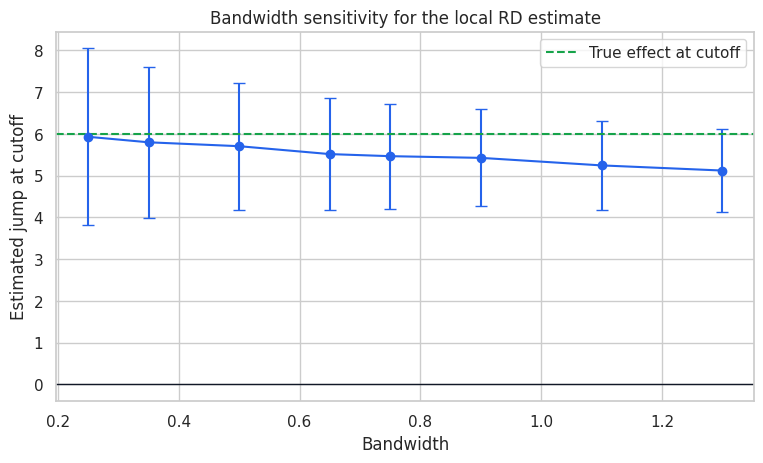

In [10]:
# Build the Bandwidth Sensitivity plot from the quantities computed above.
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.errorbar(
    bandwidth_table["bandwidth"],
    bandwidth_table["estimate"],
    yerr=1.96 * bandwidth_table["std_error"],
    fmt="o-",
    capsize=4,
    color="#2563eb",
)
ax.axhline(6.0, color="#16a34a", linestyle="--", linewidth=1.5, label="True effect at cutoff")
ax.axhline(0, color="#111827", linewidth=1)
ax.set_title("Bandwidth sensitivity for the local RD estimate")
ax.set_xlabel("Bandwidth")
ax.set_ylabel("Estimated jump at cutoff")
ax.legend()
plt.show()

The point estimates should not be identical across bandwidths. That is normal. What we want is a stable qualitative conclusion and a reasonable range of estimates. A result that appears only for one bandwidth and disappears everywhere else is usually a weak business finding.

## 6. Using `rdrobust`

The manual estimator is useful because it makes the design mechanics visible. In applied work, many analysts use specialized RD software. The `rdrobust` family implements data-driven bandwidth selection and robust bias-corrected inference; Calonico, Cattaneo, and Titiunik (2014) discuss why conventional confidence intervals can perform poorly near the boundary.

Here we run the Python `rdrobust` package on the same simulated example.

In [11]:
# Organize the calculation into readable steps for the lecture narrative.
if rdrobust is None:
    display(
        Markdown(
            "**Optional `rdrobust` check skipped.** Install `rdrobust` to run the robust "
            "bias-corrected RD estimator. The manual local-linear estimator above remains "
            "available and is the main teaching object in this notebook."
        )
    )
else:
    rdrobust_result = rdrobust(
        y=df_rdd["renewal_margin"].to_numpy(),
        x=df_rdd["risk_score"].to_numpy(),
        c=0,
    )

    print("rdrobust point estimates")
    smart_display(rdrobust_result.coef.round(3))
    print("rdrobust standard errors")
    smart_display(rdrobust_result.se.round(3))
    print("rdrobust confidence intervals")
    smart_display(rdrobust_result.ci.round(3))
    print("rdrobust bandwidths")
    smart_display(rdrobust_result.bws.round(3))

rdrobust point estimates


,Coeff
Conventional,5.645
Bias-Corrected,5.750
Robust,5.750


rdrobust standard errors


,Std. Err.
Conventional,0.760
Bias-Corrected,0.760
Robust,0.912


rdrobust confidence intervals


,CI Lower,CI Upper
Conventional,4.155,7.134
Bias-Corrected,4.261,7.240
Robust,3.963,7.537


rdrobust bandwidths


,left,right
h,0.546,0.546
b,0.841,0.841


The exact manual estimate and the `rdrobust` estimate need not match because `rdrobust` selects bandwidths and implements additional bias-correction machinery. It is useful to report both a transparent specification and a modern robust specification.

## 7. Why Global Polynomial Fits Are Risky

A tempting shortcut is to fit one polynomial over the whole running-score range and read off the jump at zero. This can be fragile because far-away data influence the shape of the curve near the cutoff.

Lee and Lemieux (2010) and later RD guidance strongly emphasize graphical checks and local estimation. The estimand is a discontinuity at one boundary, so the full outcome curve is secondary.

In [12]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def fit_global_polynomial_rd(data, outcome, score, cutoff=0.0, degree=1):
    """Fit a global polynomial RD sensitivity model.

    Args:
        data: Analysis DataFrame containing the variables used by the helper.
        outcome: Outcome variable name or vector being analyzed.
        score: Running variable or propensity score used by the design.
        cutoff: Threshold defining assignment or the RD comparison point.
        degree: Average network degree or polynomial degree, depending on the helper context.

    Returns:
        dict: Global polynomial RD estimate and fitted model summary values.
    """
    work = data.copy()
    work["running"] = work[score] - cutoff
    work["treated_side"] = (work[score] >= cutoff).astype(int)
    design_cols = ["treated_side"]
    for power in range(1, degree + 1):
        term = f"running_{power}"
        interaction = f"treated_x_running_{power}"
        work[term] = work["running"] ** power
        work[interaction] = work["treated_side"] * work[term]
        design_cols.extend([term, interaction])

    X = sm.add_constant(work[design_cols], has_constant="add")
    model = sm.OLS(work[outcome], X).fit(cov_type="HC1")
    estimate = float(model.params["treated_side"])
    se = float(model.bse["treated_side"])
    return {
        "degree": degree,
        "estimate": estimate,
        "std_error": se,
        "ci_low": estimate - 1.96 * se,
        "ci_high": estimate + 1.96 * se,
        "p_value": float(model.pvalues["treated_side"]),
        "model": model,
    }

poly_table = pd.DataFrame(
    [
        {k: v for k, v in fit_global_polynomial_rd(df_rdd, "renewal_margin", "risk_score", degree=d).items() if k != "model"}
        for d in range(1, 6)
    ]
)
smart_display(poly_table.round(3))

,degree,estimate,std_error,ci_low,ci_high,p_value
0,1,1.829,0.426,0.993,2.665,0.000
1,2,7.243,0.556,6.154,8.333,0.000
2,3,5.033,0.704,3.654,6.413,0.000
3,4,5.836,0.855,4.159,7.512,0.000
4,5,5.717,1.012,3.734,7.699,0.000


In Why Global Polynomial Fits Are Risky, the output should make you ask whether the fitted curve is helping locally or imposing structure from far away. RD credibility lives near the cutoff.

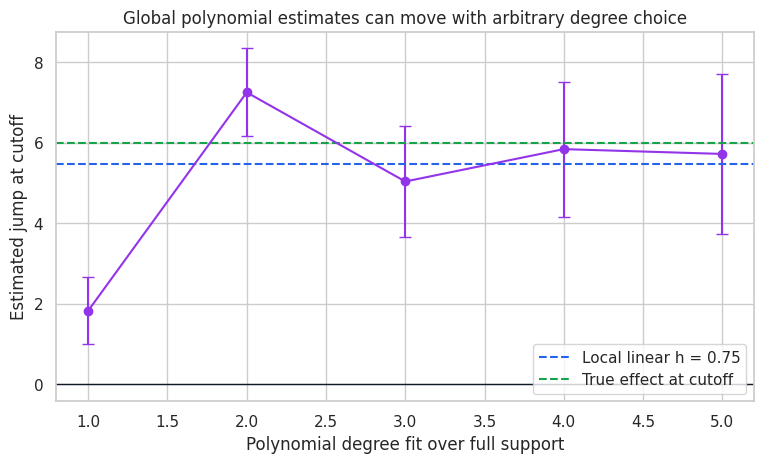

In [13]:
# Build the Why Global Polynomial Fits Are Risky plot from the quantities computed above.
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.errorbar(
    poly_table["degree"],
    poly_table["estimate"],
    yerr=1.96 * poly_table["std_error"],
    fmt="o-",
    capsize=4,
    color="#9333ea",
)
ax.axhline(main_rd["estimate"], color="#2563eb", linestyle="--", linewidth=1.5, label="Local linear h = 0.75")
ax.axhline(6.0, color="#16a34a", linestyle="--", linewidth=1.5, label="True effect at cutoff")
ax.axhline(0, color="#111827", linewidth=1)
ax.set_title("Global polynomial estimates can move with arbitrary degree choice")
ax.set_xlabel("Polynomial degree fit over full support")
ax.set_ylabel("Estimated jump at cutoff")
ax.legend()
plt.show()

This table is not meant to find the best global polynomial. It is meant to discourage treating global curve choice as a causal design. RD credibility comes from local comparison, not from making a curve flexible enough to pass through the entire data cloud.

## 8. Covariate Balance at the Cutoff

Pre-treatment covariates should not jump at the cutoff if units cannot precisely sort and the threshold rule is the only thing changing discontinuously. This is not a proof of validity, but it is a powerful diagnostic.

We test for local discontinuities in variables determined before treatment:

- prior spending
- recent usage
- enterprise plan status

In [14]:
# Assemble the Covariate Balance at the Cutoff summary table used for interpretation.
covariate_rows = []
for covariate in ["pre_spend", "usage_last_30", "enterprise_plan"]:
    fitted = fit_local_linear_rd(
        df_rdd,
        outcome=covariate,
        score="risk_score",
        bandwidth=0.75,
    )
    covariate_rows.append(result_row(covariate, fitted))

covariate_balance = pd.DataFrame(covariate_rows)
smart_display(covariate_balance.round(3))

,specification,estimate,std_error,ci_low,ci_high,p_value,bandwidth,n,n_left,n_right
0,pre_spend,0.453,0.846,-1.206,2.112,0.592,0.750,3618,1819,1799
1,usage_last_30,-0.143,0.434,-0.993,0.707,0.741,0.750,3618,1819,1799
2,enterprise_plan,-0.026,0.035,-0.095,0.043,0.457,0.750,3618,1819,1799


In Covariate Balance at the Cutoff, the table keeps attention on the neighborhood around the cutoff. These diagnostics tell us whether the threshold neighborhood behaves like a credible comparison.

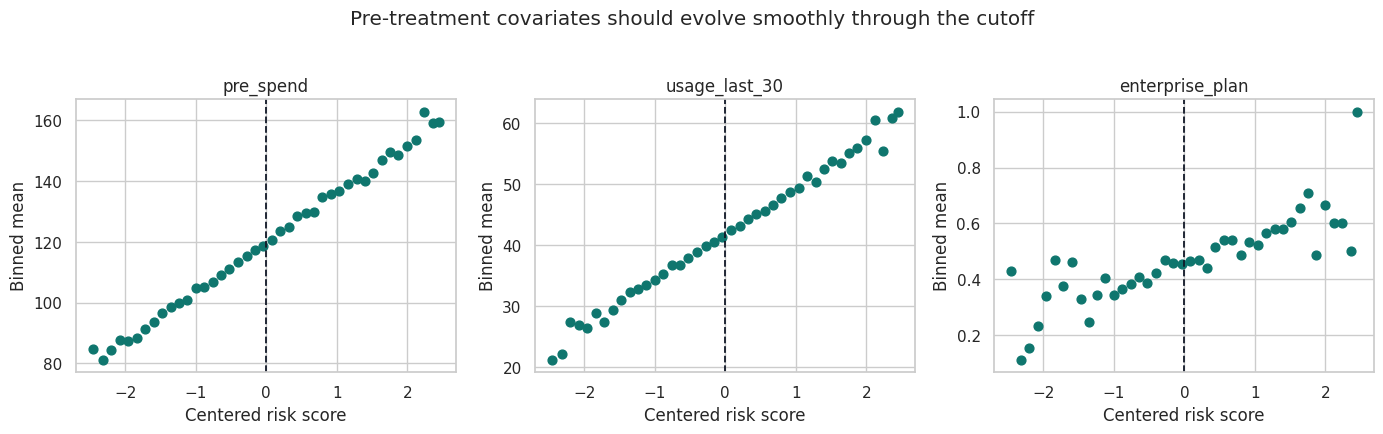

In [15]:
# Build the Covariate Balance at the Cutoff plot from the quantities computed above.
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, covariate in zip(axes, ["pre_spend", "usage_last_30", "enterprise_plan"]):
    binned = make_rd_bins(df_rdd, "risk_score", covariate, bin_width=0.12)
    ax.scatter(binned["score_mid"], binned["outcome_mean"], color="#0f766e", s=40)
    ax.axvline(0, color="#111827", linestyle="--", linewidth=1.3)
    ax.set_title(covariate)
    ax.set_xlabel("Centered risk score")
    ax.set_ylabel("Binned mean")
plt.suptitle("Pre-treatment covariates should evolve smoothly through the cutoff", y=1.03)
plt.tight_layout()
plt.show()

Small estimated jumps can occur by sampling noise, especially for binary covariates. The red flag is a large, systematic discontinuity in variables that treatment could not have affected.

## 9. Density and Manipulation Checks

McCrary (2008) formalized a density test for manipulation of the running variable. The intuition is straightforward: if units can precisely manipulate the score to land on the preferred side, the density of the running variable may jump at the cutoff.

Below is a simple symmetric-window diagnostic. It is an analyst-facing screen that complements a formal McCrary or Cattaneo-Jansson-Ma density test.

In [16]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def symmetric_density_table(data, score, cutoff=0.0, windows=(0.15, 0.25, 0.40, 0.60, 0.80, 1.00)):
    """
    Count observations in symmetric windows around an RD cutoff.
    
    Idea:
        The table is a simple manipulation diagnostic that checks whether units bunch more on one side of the threshold.
    
    Args:
        data: Analysis DataFrame containing the variables required by the model or diagnostic.
        score: Running-variable column used to position observations around the cutoff.
        cutoff: Threshold defining treatment assignment in the RD design.
        windows: Symmetric window widths around the cutoff used for density checks.
    
    Returns:
        pandas.DataFrame: Window-by-window counts, treatment-side shares, and binomial p-values.
    """
    rows = []
    x = data[score] - cutoff
    for window in windows:
        left = int(((x >= -window) & (x < 0)).sum())
        right = int(((x >= 0) & (x <= window)).sum())
        total = left + right
        p_value = stats.binomtest(right, total, p=0.5).pvalue if total > 0 else np.nan
        rows.append(
            {
                "window": window,
                "left_count": left,
                "right_count": right,
                "right_share": right / total if total else np.nan,
                "binomial_p_value": p_value,
            }
        )
    return pd.DataFrame(rows)

clean_density = symmetric_density_table(df_rdd, "risk_score")
smart_display(clean_density.round(3))

,window,left_count,right_count,right_share,binomial_p_value
0,0.150,411,376,0.478,0.226
1,0.250,691,635,0.479,0.131
2,0.400,1041,995,0.489,0.319
3,0.600,1516,1488,0.495,0.622
4,0.800,1916,1888,0.496,0.662
5,1.000,2255,2164,0.490,0.176


In Density and Manipulation Checks, the output is part of the local design audit. A jump in the running-variable density near the cutoff would make the threshold comparison much harder to trust.

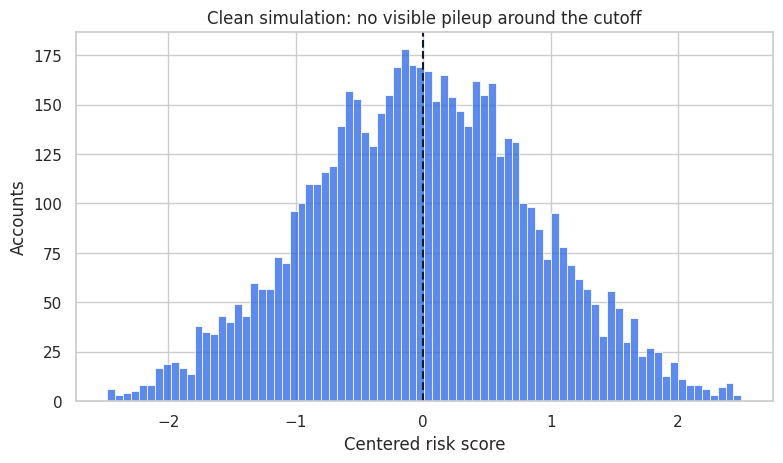

In [17]:
fig, ax = plt.subplots(figsize=(9, 4.8))
sns.histplot(df_rdd, x="risk_score", bins=80, color="#2563eb", ax=ax)
ax.axvline(0, color="#111827", linestyle="--", linewidth=1.5)
ax.set_title("Clean simulation: no visible pileup around the cutoff")
ax.set_xlabel("Centered risk score")
ax.set_ylabel("Accounts")
plt.show()

The density is not required to be perfectly symmetric. But a strong pileup just above the threshold would raise design concerns, especially if the threshold is known to account managers, customers, vendors, or internal teams who can game the score.

## 10. Placebo Cutoffs

A good RD design should show a jump at the true treatment threshold, not at arbitrary fake thresholds where the policy does not change.

Placebo cutoffs are useful falsification checks, with the caveat that the outcome curve can be noisy.

In [18]:
# Assemble the Placebo Cutoffs summary table used for interpretation.
placebo_cutoffs = [-1.20, -0.90, -0.60, -0.30, 0.30, 0.60, 0.90, 1.20]
placebo_rows = []
for fake_cutoff in placebo_cutoffs:
    fitted = fit_local_linear_rd(
        df_rdd,
        outcome="renewal_margin",
        score="risk_score",
        cutoff=fake_cutoff,
        bandwidth=0.25,
    )
    placebo_rows.append(result_row(f"cutoff = {fake_cutoff:.2f}", fitted))

placebo_table = pd.DataFrame(placebo_rows)
smart_display(placebo_table.round(3))

,specification,estimate,std_error,ci_low,ci_high,p_value,bandwidth,n,n_left,n_right
0,cutoff = -1.20,0.720,1.846,-2.898,4.338,0.697,0.250,542,215,327
1,cutoff = -0.90,-0.106,1.309,-2.671,2.459,0.935,0.250,825,346,479
2,cutoff = -0.60,-0.103,1.262,-2.577,2.370,0.935,0.250,1071,488,583
3,cutoff = -0.30,0.365,1.214,-2.015,2.745,0.764,0.250,1247,565,682
4,cutoff = 0.30,0.044,1.100,-2.112,2.200,0.968,0.250,1245,632,613
5,cutoff = 0.60,0.953,1.209,-1.416,3.322,0.430,0.250,1094,610,484
6,cutoff = 0.90,-1.471,1.527,-4.465,1.523,0.336,0.250,777,444,333
7,cutoff = 1.20,-0.113,1.666,-3.378,3.152,0.946,0.250,520,317,203


In Placebo Cutoffs, the table keeps attention on the neighborhood around the cutoff. RD evidence is strongest when the local estimate survives the usual bandwidth and validity checks.

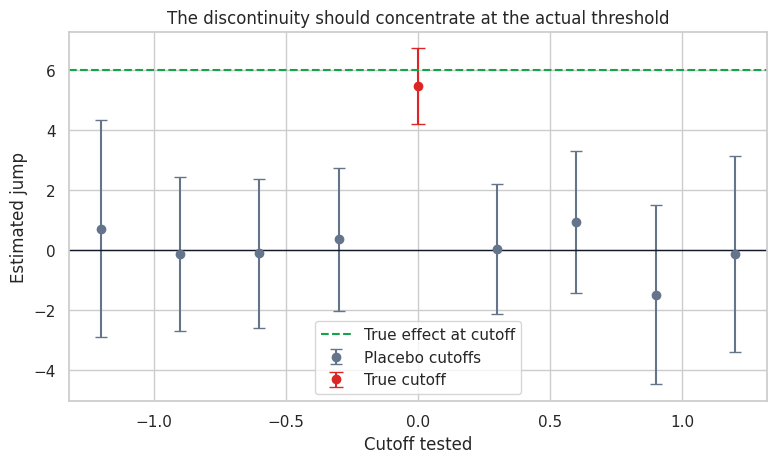

In [19]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.errorbar(
    placebo_table["bandwidth"] * 0 + placebo_cutoffs,
    placebo_table["estimate"],
    yerr=1.96 * placebo_table["std_error"],
    fmt="o",
    capsize=4,
    color="#64748b",
    label="Placebo cutoffs",
)
ax.errorbar(
    [0],
    [main_rd["estimate"]],
    yerr=[1.96 * main_rd["se"]],
    fmt="o",
    capsize=5,
    color="#dc2626",
    label="True cutoff",
)
ax.axhline(0, color="#111827", linewidth=1)
ax.axhline(6.0, color="#16a34a", linestyle="--", linewidth=1.5, label="True effect at cutoff")
ax.set_title("The discontinuity should concentrate at the actual threshold")
ax.set_xlabel("Cutoff tested")
ax.set_ylabel("Estimated jump")
ax.legend()
plt.show()

A single placebo estimate may be nonzero by chance. The pattern matters. If large jumps appear all over the running variable, the analyst should question whether the model is capturing the threshold policy or merely fitting curvature and noise.

## 11. Donut RD

A donut RD removes observations extremely close to the cutoff and refits the model. This is helpful when there is concern about small-scale manipulation, measurement heaping, manual overrides, or operational exceptions right at the threshold.

The tradeoff is real: removing the closest observations can reduce bias from sorting, but it also removes the observations most relevant to the local estimand.

In [20]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def fit_donut_rd(data, outcome, score, bandwidth=0.75, donut=0.0):
    """Fit an RD estimate after excluding observations closest to the cutoff.

    Args:
        data: Analysis DataFrame containing the variables used by the helper.
        outcome: Outcome variable name or vector being analyzed.
        score: Running variable or propensity score used by the design.
        bandwidth: Local window around the cutoff used for RD estimation.
        donut: Radius around the cutoff excluded in a donut RD sensitivity check.

    Returns:
        dict: Donut RD estimate and diagnostics.
    """
    work = data.loc[data[score].abs() > donut].copy()
    return fit_local_linear_rd(work, outcome=outcome, score=score, bandwidth=bandwidth)

donut_rows = []
for donut in [0.00, 0.03, 0.06, 0.10, 0.15, 0.20]:
    fitted = fit_donut_rd(df_rdd, "renewal_margin", "risk_score", bandwidth=0.75, donut=donut)
    row = result_row(f"donut = {donut:.2f}", fitted)
    row["donut"] = donut
    donut_rows.append(row)

donut_table = pd.DataFrame(donut_rows)
smart_display(donut_table.round(3))

,specification,estimate,std_error,ci_low,ci_high,p_value,bandwidth,n,n_left,n_right,donut
0,donut = 0.00,5.467,0.640,4.212,6.722,0.000,0.750,3618,1819,1799,0.000
1,donut = 0.03,5.545,0.705,4.162,6.928,0.000,0.750,3457,1735,1722,0.030
2,donut = 0.06,4.918,0.777,3.396,6.440,0.000,0.750,3284,1649,1635,0.060
3,donut = 0.10,5.009,0.898,3.250,6.768,0.000,0.750,3084,1542,1542,0.100
4,donut = 0.15,5.162,1.061,3.082,7.242,0.000,0.750,2831,1408,1423,0.150
5,donut = 0.20,4.151,1.294,1.615,6.686,0.001,0.750,2543,1261,1282,0.200


In Donut RD, the table keeps attention on the neighborhood around the cutoff. Bandwidth sensitivity, covariate continuity, density checks, and placebo cutoffs are the credibility checks for the local contrast.

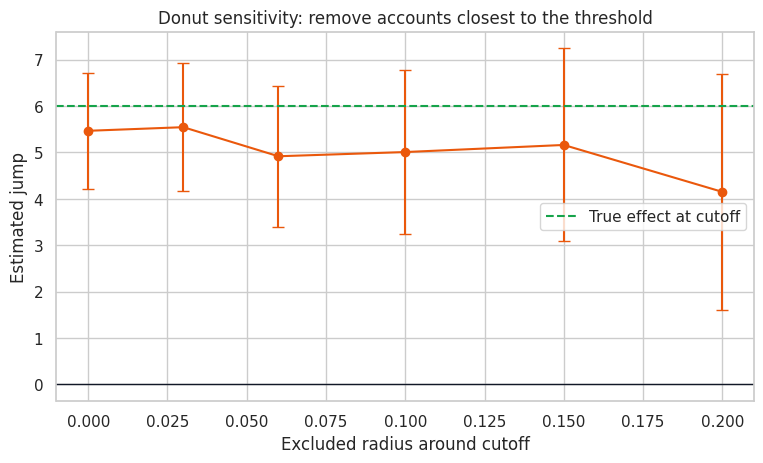

In [21]:
# Build the Donut RD plot from the quantities computed above.
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.errorbar(
    donut_table["donut"],
    donut_table["estimate"],
    yerr=1.96 * donut_table["std_error"],
    fmt="o-",
    capsize=4,
    color="#ea580c",
)
ax.axhline(6.0, color="#16a34a", linestyle="--", linewidth=1.5, label="True effect at cutoff")
ax.axhline(0, color="#111827", linewidth=1)
ax.set_title("Donut sensitivity: remove accounts closest to the threshold")
ax.set_xlabel("Excluded radius around cutoff")
ax.set_ylabel("Estimated jump")
ax.legend()
plt.show()

In this clean simulation, donut estimates should remain broadly similar. In real data, a large change after removing a tiny region around the cutoff is an important warning sign.

## 12. Failure Mode: Sorting Around the Cutoff

Now we simulate a problematic setting. Some accounts that would have landed just below the threshold are moved just above it. This could happen if customer success managers know the rule and manually adjust inputs, or if customers change behavior to cross the threshold.

This breaks the clean local comparison. Units just above the cutoff are no longer the natural neighbors of units just below it.

In [22]:
# Assemble the Failure Mode: Sorting Around the Cutoff summary table used for interpretation.
df_manipulated = simulate_rdd_data(seed=5505, manipulation=True)

manipulated_rd = fit_local_linear_rd(
    df_manipulated,
    outcome="renewal_margin",
    score="risk_score",
    bandwidth=0.75,
)

comparison = pd.DataFrame(
    [
        result_row("Clean threshold", main_rd),
        result_row("Manipulated score", manipulated_rd),
    ]
)
smart_display(comparison.round(3))

,specification,estimate,std_error,ci_low,ci_high,p_value,bandwidth,n,n_left,n_right
0,Clean threshold,5.467,0.640,4.212,6.722,0.000,0.750,3618,1819,1799
1,Manipulated score,4.647,0.711,3.253,6.041,0.000,0.750,3618,1462,2156


In Failure Mode: Sorting Around the Cutoff, the table keeps attention on the neighborhood around the cutoff. The local contrast earns trust through bandwidth, covariate, density, and placebo checks.

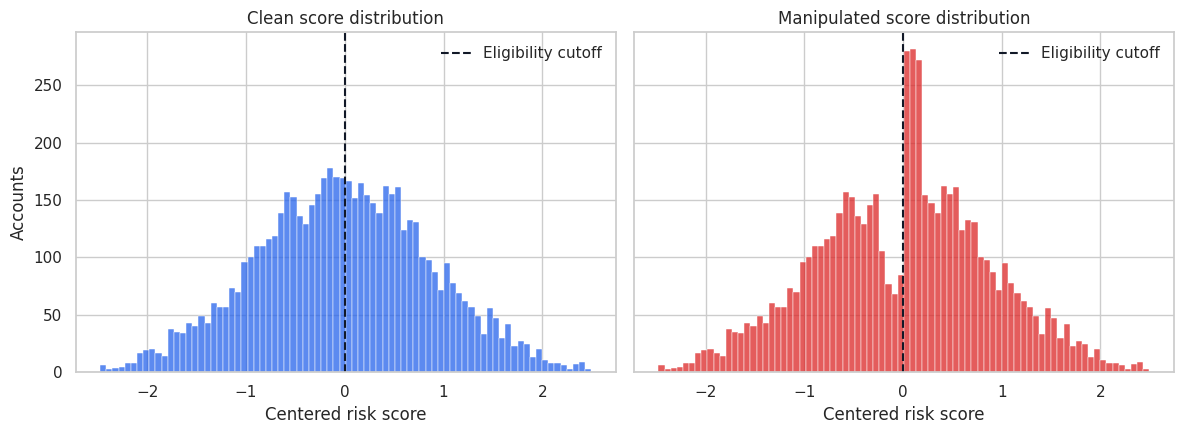

In [23]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

sns.histplot(df_rdd, x="risk_score", bins=80, color="#2563eb", ax=axes[0])
axes[0].axvline(0, color="#111827", linestyle="--", linewidth=1.5, label="Eligibility cutoff")
axes[0].set_title("Clean score distribution")
axes[0].set_xlabel("Centered risk score")
axes[0].set_ylabel("Accounts")
axes[0].legend(frameon=False)

sns.histplot(df_manipulated, x="risk_score", bins=80, color="#dc2626", ax=axes[1])
axes[1].axvline(0, color="#111827", linestyle="--", linewidth=1.5, label="Eligibility cutoff")
axes[1].set_title("Manipulated score distribution")
axes[1].set_xlabel("Centered risk score")
axes[1].set_ylabel("Accounts")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

In Failure Mode: Sorting Around the Cutoff, the figure keeps attention on the neighborhood around the cutoff. These diagnostics tell us whether the threshold neighborhood behaves like a credible comparison.

In [24]:
print("Clean density diagnostic")
smart_display(symmetric_density_table(df_rdd, "risk_score").round(3))
print("Manipulated density diagnostic")
smart_display(symmetric_density_table(df_manipulated, "risk_score").round(3))

Clean density diagnostic


,window,left_count,right_count,right_share,binomial_p_value
0,0.150,411,376,0.478,0.226
1,0.250,691,635,0.479,0.131
2,0.400,1041,995,0.489,0.319
3,0.600,1516,1488,0.495,0.622
4,0.800,1916,1888,0.496,0.662
5,1.000,2255,2164,0.490,0.176


Manipulated density diagnostic


,window,left_count,right_count,right_share,binomial_p_value
0,0.150,166,663,0.800,0.000
1,0.250,334,992,0.748,0.000
2,0.400,684,1352,0.664,0.000
3,0.600,1159,1845,0.614,0.000
4,0.800,1559,2245,0.590,0.000
5,1.000,1898,2521,0.570,0.000


The manipulated data create visible sorting around the threshold. In real work, this is where the causal conversation should slow down. You might still analyze the policy, but the clean sharp RD story is no longer enough.

## 13. Covariate Adjustment

Covariates are not required for identification in the canonical sharp RD. The running variable and cutoff are the design. However, pre-treatment covariates can improve precision and help diagnose imbalance. Modern RD guidance treats covariate adjustment carefully because covariates should not be used to rescue a broken threshold design.

Here we add pre-treatment spending, recent usage, and enterprise status to the local regression. The treatment coefficient remains the jump at the cutoff, adjusted for smooth pre-treatment predictors.

In [25]:
# Assemble the Covariate Adjustment summary table used for interpretation.
adjusted_rd = fit_local_linear_rd(
    df_rdd,
    outcome="renewal_margin",
    score="risk_score",
    bandwidth=0.75,
    covariates=["pre_spend", "usage_last_30", "enterprise_plan"],
)

adjustment_table = pd.DataFrame(
    [
        result_row("Unadjusted local linear", main_rd),
        result_row("Covariate-adjusted local linear", adjusted_rd),
    ]
)
smart_display(adjustment_table.round(3))

,specification,estimate,std_error,ci_low,ci_high,p_value,bandwidth,n,n_left,n_right
0,Unadjusted local linear,5.467000,0.640000,4.212000,6.722000,0.000000,0.750000,3618,1819,1799
1,Covariate-adjusted local linear,5.571000,0.599000,4.396000,6.745000,0.000000,0.750000,3618,1819,1799


If covariate adjustment dramatically changes the estimate, investigate why. A modest precision gain is normal. A large movement may indicate that the local comparison was imbalanced or that the bandwidth is too wide.

## 14. Fuzzy RD Preview

Many real threshold policies are fuzzy. Crossing the threshold may trigger an offer, escalation, notification, or eligibility flag, but not everyone receives or complies with the treatment.

In fuzzy RD, the cutoff is an instrument for treatment receipt. The estimand is a local Wald ratio:

$$
\tau_{FRD} = \frac{\lim_{x \downarrow c}E[Y_i \mid X_i=x] - \lim_{x \uparrow c}E[Y_i \mid X_i=x]}{\lim_{x \downarrow c}E[D_i \mid X_i=x] - \lim_{x \uparrow c}E[D_i \mid X_i=x]}
$$

The numerator is the reduced-form jump in the outcome. The denominator is the first-stage jump in treatment receipt. This connects directly to instrumental variables, which is the next notebook.

In [26]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def simulate_fuzzy_rdd_data(n=6000, seed=5515):
    """Generate a fuzzy RD dataset with imperfect treatment take-up at the cutoff.

    Args:
        n: Number of simulated units.
        seed: Random seed for reproducible simulation or resampling.

    Returns:
        pandas.DataFrame: Simulated dataset with observed variables and any known truth columns used for teaching.
    """
    rng = np.random.default_rng(seed)
    score = bounded_normal(rng, n)
    eligibility = (score >= 0).astype(int)

    pre_spend = 118 + 14 * score + rng.normal(0, 12, size=n)
    usage_last_30 = 41 + 7 * score + rng.normal(0, 6, size=n)
    base_takeup = 0.18 + 0.08 * score
    takeup_probability = np.clip(base_takeup + 0.58 * eligibility, 0.03, 0.95)
    received_support = rng.binomial(1, takeup_probability, size=n)

    true_effect = 8.0 + 0.5 * score
    untreated_margin = (
        58
        + 0.09 * pre_spend
        + 0.36 * usage_last_30
        + 7.0 * score
        - 5.0 * score**2
        + rng.normal(0, 8.5, size=n)
    )
    renewal_margin = untreated_margin + received_support * true_effect

    return pd.DataFrame(
        {
            "risk_score": score,
            "eligibility": eligibility,
            "received_support": received_support,
            "renewal_margin": renewal_margin,
            "pre_spend": pre_spend,
            "usage_last_30": usage_last_30,
            "true_effect": true_effect,
        }
    )


df_fuzzy = simulate_fuzzy_rdd_data()
reduced_form = fit_local_linear_rd(df_fuzzy, "renewal_margin", "risk_score", bandwidth=0.75)
first_stage = fit_local_linear_rd(df_fuzzy, "received_support", "risk_score", bandwidth=0.75)
fuzzy_effect = reduced_form["estimate"] / first_stage["estimate"]

fuzzy_table = pd.DataFrame(
    [
        result_row("Reduced form: outcome jump", reduced_form),
        result_row("First stage: treatment jump", first_stage),
    ]
)
smart_display(fuzzy_table.round(3))
print(f"Local Wald fuzzy RD estimate: {fuzzy_effect:.2f}")
print("True treatment effect at cutoff in this fuzzy simulation: 8.00")

,specification,estimate,std_error,ci_low,ci_high,p_value,bandwidth,n,n_left,n_right
0,Reduced form: outcome jump,5.400,0.662,4.102,6.698,0.000,0.750,3590,1784,1806
1,First stage: treatment jump,0.591,0.028,0.536,0.646,0.000,0.750,3590,1784,1806


Local Wald fuzzy RD estimate: 9.14
True treatment effect at cutoff in this fuzzy simulation: 8.00


In Fuzzy RD Preview, the table keeps attention on the neighborhood around the cutoff. RD evidence is strongest when the local estimate survives the usual bandwidth and validity checks.

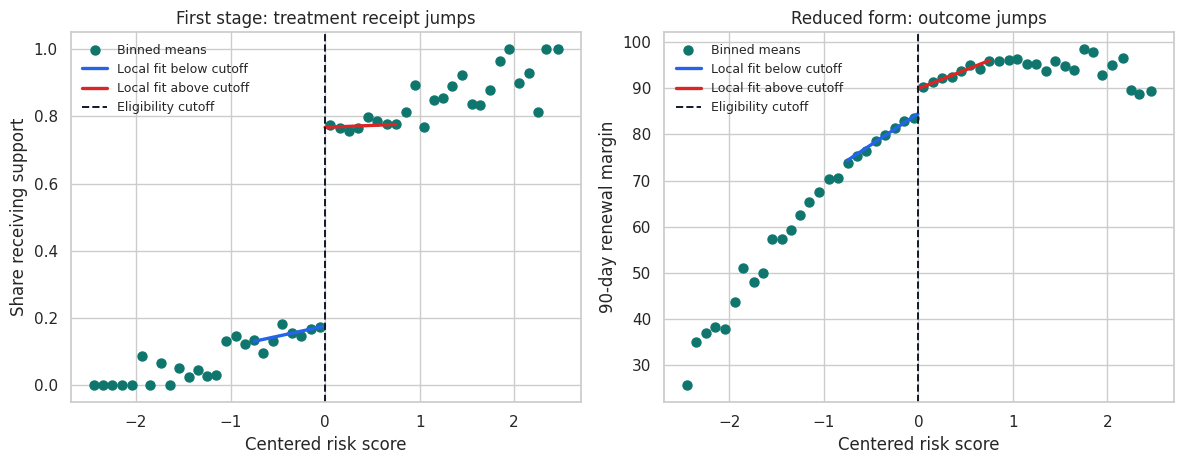

In [27]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

fuzzy_outcome = fit_local_linear_rd(df_fuzzy, "renewal_margin", "risk_score", bandwidth=0.75)
plot_rd(
    df_fuzzy,
    outcome="renewal_margin",
    score="risk_score",
    result=fuzzy_outcome,
    title="Fuzzy RD reduced form: outcome jump",
    ylabel="90-day renewal margin",
    sample_size=900,
)[0].axes[0].remove()
plt.close()

# Build compact fuzzy plots directly to keep the two-panel layout clean.
for ax, outcome, title, ylabel in [
    (axes[0], "received_support", "First stage: treatment receipt jumps", "Share receiving support"),
    (axes[1], "renewal_margin", "Reduced form: outcome jumps", "90-day renewal margin"),
]:
    fitted = fit_local_linear_rd(df_fuzzy, outcome, "risk_score", bandwidth=0.75)
    binned = make_rd_bins(df_fuzzy, "risk_score", outcome, bin_width=0.10)
    left_grid = np.linspace(-0.75, 0, 120, endpoint=False)
    right_grid = np.linspace(0, 0.75, 120)
    ax.scatter(binned["score_mid"], binned["outcome_mean"], color="#0f766e", s=42, label="Binned means")
    ax.plot(left_grid, predict_rd_line(fitted, left_grid), color="#2563eb", linewidth=2.4, label="Local fit below cutoff")
    ax.plot(right_grid, predict_rd_line(fitted, right_grid), color="#dc2626", linewidth=2.4, label="Local fit above cutoff")
    ax.axvline(0, color="#111827", linestyle="--", linewidth=1.4, label="Eligibility cutoff")
    ax.set_title(title)
    ax.set_xlabel("Centered risk score")
    ax.set_ylabel(ylabel)
    ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

Fuzzy RD is not weaker because it is fuzzy. It is answering a different question. The local Wald estimate is for compliers near the cutoff: units whose treatment receipt changed because the threshold rule changed their eligibility.

## 15. Industry Readout Template

A professional RD readout should separate the design claim from the estimate.

Design claim:

- The running variable was determined before treatment.
- The cutoff rule was known and stable during the analysis period.
- Units could not precisely manipulate the running variable around the cutoff.
- No other policy changed discontinuously at the same cutoff.
- Pre-treatment covariates look smooth through the threshold.
- The density of the running variable does not show suspicious bunching.

Estimate claim:

- The effect is local to accounts near the threshold.
- The preferred estimate comes from local linear RD with a stated bandwidth.
- The conclusion is stable across reasonable bandwidths and donut checks.
- The result is not replicated at fake thresholds.

In [28]:
# Build the summary table used to connect the calculation back to the design question.
readout = pd.DataFrame(
    {
        "item": [
            "Decision threshold",
            "Running variable",
            "Treatment",
            "Outcome",
            "Preferred estimate",
            "95% CI",
            "Bandwidth",
            "Local sample size",
            "Key diagnostics",
            "Business interpretation",
        ],
        "value": [
            "Risk score >= 0",
            "Pre-treatment customer health risk score",
            "Priority retention workflow",
            "90-day renewal margin",
            f"{main_rd['estimate']:.2f}",
            f"[{main_rd['ci_low']:.2f}, {main_rd['ci_high']:.2f}]",
            f"{main_rd['bandwidth']:.2f}",
            f"{main_rd['n']:,} accounts",
            "Bandwidth, covariates, density, placebo, donut",
            "For accounts near the threshold, priority retention support appears to increase renewal margin.",
        ],
    }
)
smart_display(readout)

,item,value
0,Decision threshold,Risk score >= 0
1,Running variable,Pre-treatment customer health risk score
2,Treatment,Priority retention workflow
3,Outcome,90-day renewal margin
4,Preferred estimate,5.47
5,95% CI,"[4.21, 6.72]"
6,Bandwidth,0.75
7,Local sample size,"3,618 accounts"
8,Key diagnostics,"Bandwidth, covariates, density, placebo, donut"
9,Business interpretation,"For accounts near the threshold, priority retention support appears to increase renewal margin."


## Key Takeaways

- RD is useful when treatment changes discontinuously at a known threshold.
- The estimand is local to the cutoff.
- The running variable can be highly predictive of the outcome; that is why the threshold design is needed.
- Local linear estimation is the workhorse specification.
- Bandwidth choice is a design decision, not a nuisance detail.
- Density checks, covariate balance, placebo cutoffs, and donut RD are central credibility checks.
- Manipulation around the cutoff can break the design.
- Fuzzy RD estimates a local Wald effect and naturally connects to instrumental variables.
- In industry, RD is often hiding in operational rules that already exist.

## 13. Real-Data Companion: Running Variables and Cutoff Discipline in STAR98

Regression discontinuity requires a real rule that changes treatment at a known cutoff. Many datasets have continuous scores, but a score alone does not make an RD design.

The California STAR98 data contain county-level education outcomes and covariates. We use the percentage of low-income students as a running variable and set an artificial 30 percent cutoff only to practice RD diagnostics. This is not a causal RD estimate. It is a realism check for density, covariate continuity, local sample size, and the danger of inventing thresholds after seeing the data.

Data source: [statsmodels STAR98 dataset](https://www.statsmodels.org/stable/datasets/generated/star98.html).

**How to read this real-data section.** The purpose here is to practice the workflow on messy data. The estimate is causal only when the design supplies credible assignment, timing, exposure, comparison groups, and assumptions.


**Real-data dataset note.** The STAR98 data contain county-level education and demographic measures. We use percent low-income students as a running variable and place an artificial cutoff only to practice RD diagnostics. There is no real assignment rule at that threshold, so the exercise is not a causal RD design. The companion is included because it shows a common temptation: a continuous running variable and a visible threshold-like split can look design-ready, but RD requires an institutional rule that changes treatment at the cutoff and cannot be precisely manipulated.

,specification,estimate,std_error,ci_low,ci_high,p_value,bandwidth,n,n_left,n_right
0,Artificial cutoff diagnostic,0.028,0.038,-0.047,0.102,0.470,12.000,117,50,67


side_of_cutoff,covariate,Above cutoff,Below cutoff,difference_above_minus_below
0,PERASIAN,5.006,5.579,-0.574
1,PERBLACK,6.919,4.661,2.258
2,PERHISP,28.375,19.266,9.109
3,AVYRSEXP,14.483,14.298,0.185


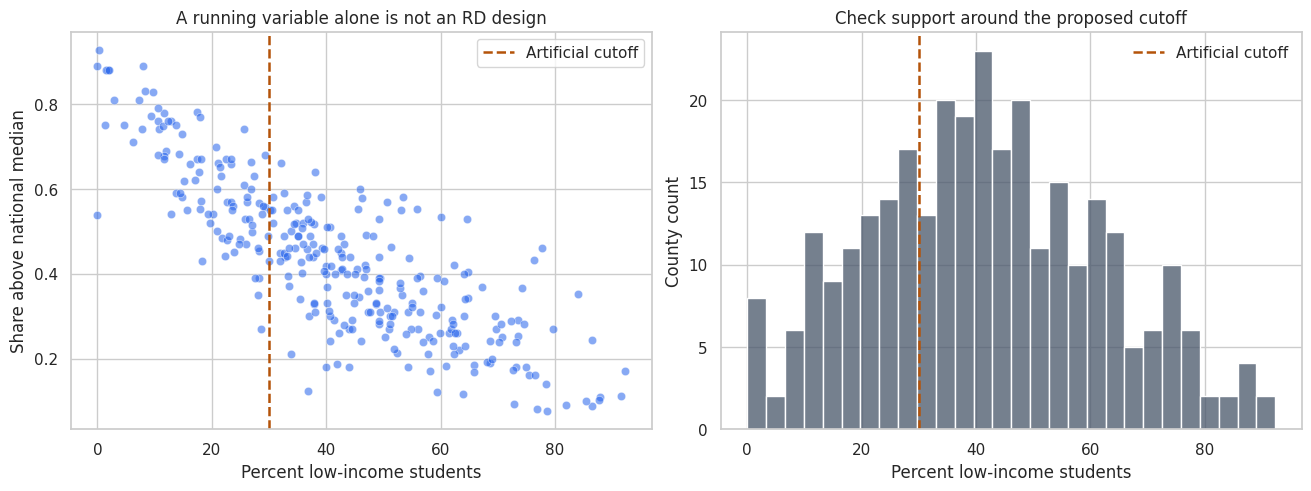

In [29]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio project root so shared notebook utilities can be imported.
    
    Idea:
        The notebooks may be executed from different working directories, so this helper walks upward until it finds the repository structure used by the lecture series.
    
    Args:
        start: Directory where the upward search for the project root begins.
    
    Returns:
        pathlib.Path: Absolute path to the portfolio project root.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.real_data import load_statsmodels_star98, optional_data_note

RUN_REAL_DATA_COMPANION = True
STAR98_SOURCE = "https://www.statsmodels.org/stable/datasets/generated/star98.html"

if RUN_REAL_DATA_COMPANION:
    star = load_statsmodels_star98().copy()
    star["share_above_median"] = star["NABOVE"] / (star["NABOVE"] + star["NBELOW"])
    star["running_low_income"] = star["LOWINC"]
    artificial_cutoff = 30.0
    bandwidth = 12.0

    star_rd = fit_local_linear_rd(
        star,
        outcome="share_above_median",
        score="running_low_income",
        cutoff=artificial_cutoff,
        bandwidth=bandwidth,
        covariates=["PERASIAN", "PERBLACK", "PERHISP", "AVYRSEXP"],
    )
    smart_display(pd.DataFrame([result_row("Artificial cutoff diagnostic", star_rd)]).round(4))

    local_star = star.loc[(star["running_low_income"] - artificial_cutoff).abs() <= bandwidth].copy()
    local_star["side_of_cutoff"] = np.where(local_star["running_low_income"] >= artificial_cutoff, "Above cutoff", "Below cutoff")

    covariate_check = (
        local_star.groupby("side_of_cutoff")[["PERASIAN", "PERBLACK", "PERHISP", "AVYRSEXP"]]
        .mean()
        .T
        .reset_index(names="covariate")
    )
    covariate_check["difference_above_minus_below"] = covariate_check["Above cutoff"] - covariate_check["Below cutoff"]
    smart_display(covariate_check.round(3))

    fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8), constrained_layout=True)
    sns.scatterplot(
        data=star,
        x="running_low_income",
        y="share_above_median",
        alpha=0.55,
        ax=axes[0],
        color="#2563eb",
    )
    axes[0].axvline(artificial_cutoff, color="#b45309", linestyle="--", linewidth=1.8, label="Artificial cutoff")
    axes[0].set_title("A running variable alone is not an RD design")
    axes[0].set_xlabel("Percent low-income students")
    axes[0].set_ylabel("Share above national median")
    axes[0].legend()

    sns.histplot(data=star, x="running_low_income", bins=28, ax=axes[1], color="#475569")
    axes[1].axvline(artificial_cutoff, color="#b45309", linestyle="--", linewidth=1.8, label="Artificial cutoff")
    axes[1].set_title("Check support around the proposed cutoff")
    axes[1].set_xlabel("Percent low-income students")
    axes[1].set_ylabel("County count")
    axes[1].legend(frameon=False)
    plt.show()
else:
    optional_data_note("STAR98 education data", STAR98_SOURCE, "RUN_REAL_DATA_COMPANION")

The companion is deliberately framed as a warning. The code can produce an RD-style number, but the design is empty unless the cutoff came from a real rule and units could not precisely manipulate their position around it.

That is the industry lesson: RD starts with institutional knowledge about the assignment rule. The running variable, bandwidth, and local regression come after that design story is credible.

## References

Calonico, S., Cattaneo, M. D., & Titiunik, R. (2014). Robust nonparametric confidence intervals for regression-discontinuity designs. *Econometrica, 82*(6), 2295-2326. [https://doi.org/10.3982/ecta11757](https://doi.org/10.3982/ecta11757)

Calonico, S., Cattaneo, M. D., & Titiunik, R. (2014). Robust data-driven inference in the regression-discontinuity design. *The Stata Journal, 14*(4), 909-946. [https://doi.org/10.1177/1536867x1401400413](https://doi.org/10.1177/1536867x1401400413)

Cattaneo, M. D., & Titiunik, R. (2022). Regression discontinuity designs. *Annual Review of Economics, 14*, 821-851. [https://doi.org/10.1146/annurev-economics-051520-021409](https://doi.org/10.1146/annurev-economics-051520-021409)

Hahn, J., Todd, P., & van der Klaauw, W. (2001). Identification and estimation of treatment effects with a regression-discontinuity design. *Econometrica, 69*(1), 201-209. [https://doi.org/10.1111/1468-0262.00183](https://doi.org/10.1111/1468-0262.00183)

Imbens, G. W., & Lemieux, T. (2008). Regression discontinuity designs: A guide to practice. *Journal of Econometrics, 142*(2), 615-635. [https://doi.org/10.1016/j.jeconom.2007.05.001](https://doi.org/10.1016/j.jeconom.2007.05.001)

Lee, D. S., & Lemieux, T. (2010). Regression discontinuity designs in economics. *Journal of Economic Literature, 48*(2), 281-355. [https://doi.org/10.1257/jel.48.2.281](https://doi.org/10.1257/jel.48.2.281)

McCrary, J. (2008). Manipulation of the running variable in the regression discontinuity design: A density test. *Journal of Econometrics, 142*(2), 698-714. [https://doi.org/10.1016/j.jeconom.2007.05.005](https://doi.org/10.1016/j.jeconom.2007.05.005)

Thistlethwaite, D. L., & Campbell, D. T. (1960). Regression-discontinuity analysis: An alternative to the ex post facto experiment. *Journal of Educational Psychology, 51*(6), 309-317. [https://doi.org/10.1037/h0044319](https://doi.org/10.1037/h0044319)